In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [25]:
import warnings
warnings.filterwarnings("ignore")

In [26]:
df = pd.read_csv("Loan_approval_data_2025.csv")

In [27]:
df.shape

(50000, 20)

In [28]:
df.head()

,customer_id,age,occupation_status,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,product_type,loan_intent,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
0,CUST100000,40,Employed,17.2,25579,692,5.3,895,10820,0,0,0,Credit Card,Business,600,17.02,0.423,0.023,0.008,1
1,CUST100001,33,Employed,7.3,43087,627,3.5,169,16550,0,1,0,Personal Loan,Home Improvement,53300,14.10,0.384,1.237,0.412,0
2,CUST100002,42,Student,1.1,20840,689,8.4,17,7852,0,0,0,Credit Card,Debt Consolidation,2100,18.33,0.377,0.101,0.034,1
3,CUST100003,53,Student,0.5,29147,692,9.8,1480,11603,0,1,0,Credit Card,Business,2900,18.74,0.398,0.099,0.033,1
4,CUST100004,32,Employed,12.5,63657,630,7.2,209,12424,0,0,0,Personal Loan,Education,99600,13.92,0.195,1.565,0.522,1


In [29]:
def get_missing_data(df):
    total = df.isnull().sum().sort_values(ascending = False)
    percent = (df.isnull().sum()/df.isnull().count()*100).sort_values(ascending = False)
    percent = round(percent,2)
    missing_df  = pd.concat([total, percent], axis=1, keys=["Total", "Percent"])
    print( missing_df.head(20))
    return None

In [30]:
get_missing_data(df)

                         Total  Percent
customer_id                  0      0.0
age                          0      0.0
payment_to_income_ratio      0      0.0
loan_to_income_ratio         0      0.0
debt_to_income_ratio         0      0.0
interest_rate                0      0.0
loan_amount                  0      0.0
loan_intent                  0      0.0
product_type                 0      0.0
derogatory_marks             0      0.0
delinquencies_last_2yrs      0      0.0
defaults_on_file             0      0.0
current_debt                 0      0.0
savings_assets               0      0.0
credit_history_years         0      0.0
credit_score                 0      0.0
annual_income                0      0.0
years_employed               0      0.0
occupation_status            0      0.0
loan_status                  0      0.0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 20 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              50000 non-null  object 
 1   age                      50000 non-null  int64  
 2   occupation_status        50000 non-null  object 
 3   years_employed           50000 non-null  float64
 4   annual_income            50000 non-null  int64  
 5   credit_score             50000 non-null  int64  
 6   credit_history_years     50000 non-null  float64
 7   savings_assets           50000 non-null  int64  
 8   current_debt             50000 non-null  int64  
 9   defaults_on_file         50000 non-null  int64  
 10  delinquencies_last_2yrs  50000 non-null  int64  
 11  derogatory_marks         50000 non-null  int64  
 12  product_type             50000 non-null  object 
 13  loan_intent              50000 non-null  object 
 14  loan_amount           

In [32]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
customer_id,50000,50000,CUST100000,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,50000.0,NaN,NaN,NaN,34.95706,11.118603,18.0,26.0,35.0,43.0,70.0
occupation_status,50000,3,Employed,34971,NaN,NaN,NaN,NaN,NaN,NaN,NaN
years_employed,50000.0,NaN,NaN,NaN,7.454868,7.612097,0.0,1.3,4.9,11.4,39.9
annual_income,50000.0,NaN,NaN,NaN,50062.89204,32630.501014,15000.0,27280.5,41607.5,62723.25,250000.0
credit_score,50000.0,NaN,NaN,NaN,643.61482,64.731518,348.0,600.0,643.0,687.0,850.0
credit_history_years,50000.0,NaN,NaN,NaN,8.168274,7.207552,0.0,2.0,6.1,12.6,30.0
savings_assets,50000.0,NaN,NaN,NaN,3595.6194,13232.399398,0.0,130.0,568.0,2271.0,300000.0
current_debt,50000.0,NaN,NaN,NaN,14290.44222,13243.757493,60.0,5581.0,10385.0,18449.25,163344.0
defaults_on_file,50000.0,NaN,NaN,NaN,0.05348,0.224991,0.0,0.0,0.0,0.0,1.0


In [33]:
df.duplicated().sum()

0

In [34]:
num_columns = df.select_dtypes(include=["int64", "float64"]).columns.tolist()
df[num_columns].describe()

,age,years_employed,annual_income,credit_score,credit_history_years,savings_assets,current_debt,defaults_on_file,delinquencies_last_2yrs,derogatory_marks,loan_amount,interest_rate,debt_to_income_ratio,loan_to_income_ratio,payment_to_income_ratio,loan_status
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,34.957060,7.454868,50062.892040,643.614820,8.168274,3595.619400,14290.442220,0.053480,0.55464,0.147640,33041.874000,15.498591,0.285724,0.701999,0.233995,0.550460
std,11.118603,7.612097,32630.501014,64.731518,7.207552,13232.399398,13243.757493,0.224991,0.84505,0.412996,26116.185102,4.067942,0.159787,0.465788,0.155268,0.497452
min,18.000000,0.000000,15000.000000,348.000000,0.000000,0.000000,60.000000,0.000000,0.00000,0.000000,500.000000,6.000000,0.002000,0.008000,0.003000,0.000000
25%,26.000000,1.300000,27280.500000,600.000000,2.000000,130.000000,5581.000000,0.000000,0.00000,0.000000,12300.000000,12.180000,0.161000,0.333000,0.111000,0.000000
50%,35.000000,4.900000,41607.500000,643.000000,6.100000,568.000000,10385.000000,0.000000,0.00000,0.000000,26100.000000,15.440000,0.265000,0.622000,0.207000,1.000000
75%,43.000000,11.400000,62723.250000,687.000000,12.600000,2271.000000,18449.250000,0.000000,1.00000,0.000000,48500.000000,18.870000,0.389000,1.010250,0.337000,1.000000
max,70.000000,39.900000,250000.000000,850.000000,30.000000,300000.000000,163344.000000,1.000000,9.00000,4.000000,100000.000000,23.000000,0.800000,2.001000,0.667000,1.000000


In [35]:
cat_columns = df.select_dtypes(include=["object"]).columns.tolist()
cat_columns.remove("customer_id")
df[cat_columns].describe()

,occupation_status,product_type,loan_intent
count,50000,50000,50000
unique,3,3,6
top,Employed,Credit Card,Personal
freq,34971,22455,12429


In [36]:
df["loan_status"].value_counts()

loan_status
1    27523
0    22477
Name: count, dtype: int64

In [37]:
df["product_type"].value_counts()

product_type
Credit Card       22455
Personal Loan     17523
Line of Credit    10022
Name: count, dtype: int64

In [38]:
df["loan_intent"].value_counts()

loan_intent
Personal              12429
Education             10134
Medical                7598
Business               7469
Home Improvement       7453
Debt Consolidation     4917
Name: count, dtype: int64

# Exploratory DA ------------------------------------------------------------------

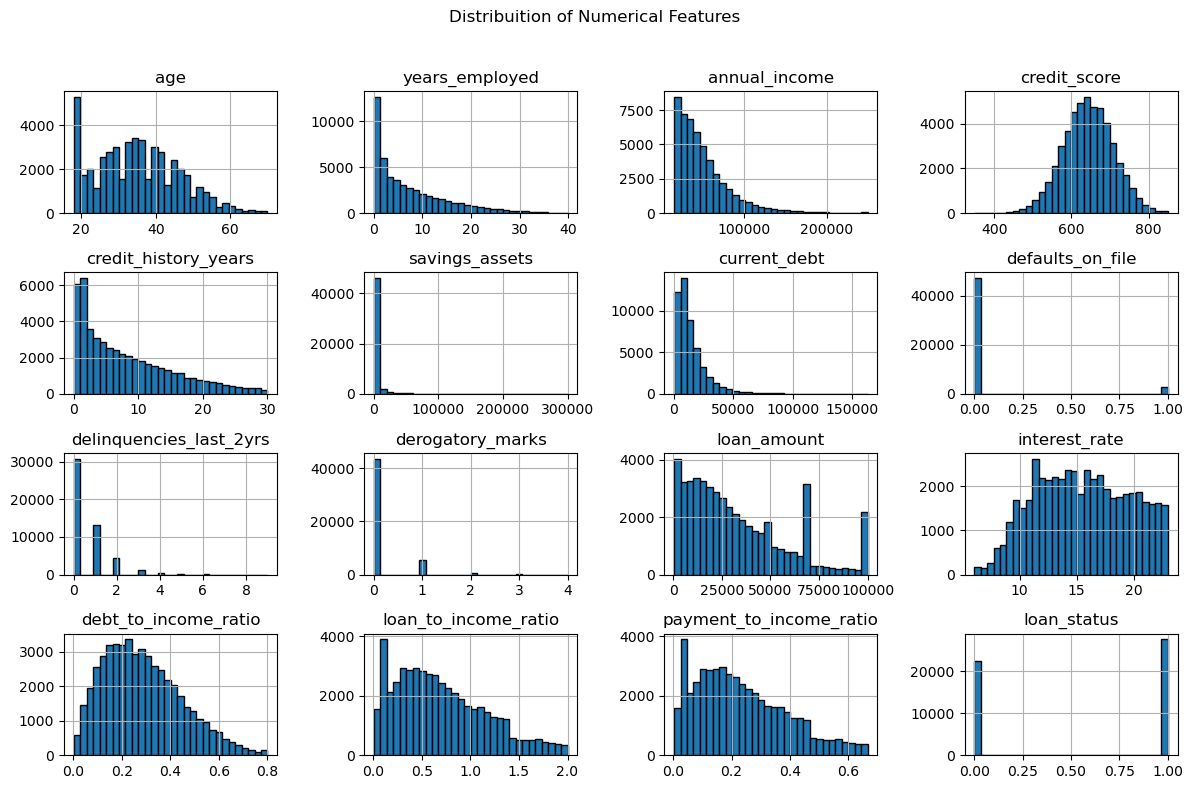

In [39]:
df[num_columns].hist(bins = 30, edgecolor= "black", figsize = (12, 8))
plt.suptitle("Distribuition of Numerical Features", fontsize = 12)
plt.tight_layout(rect = [0, 0, 1, 0.96])
plt.show()

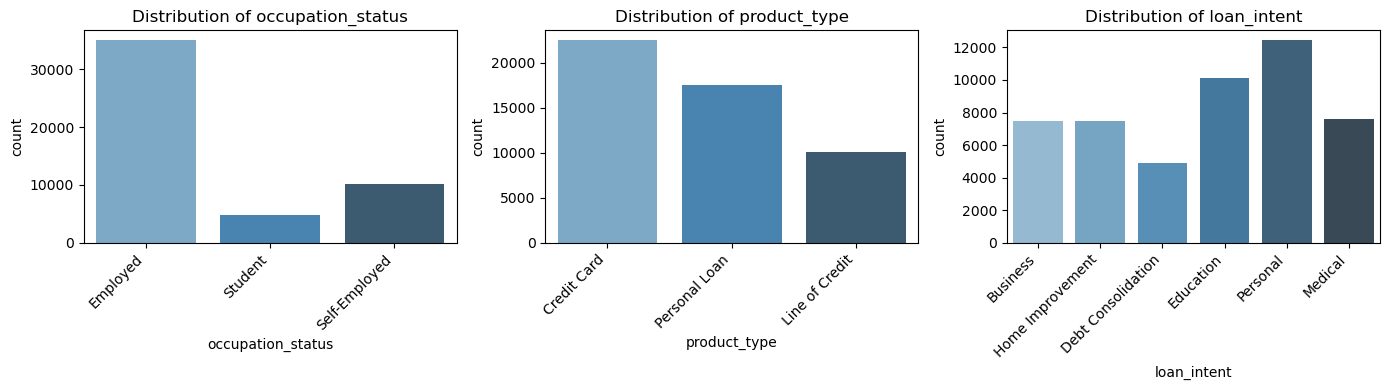

In [40]:
n = len(cat_columns)
nrows = math.ceil(n / 3)

plt.figure(figsize = (14, 4 * nrows))

for i, col in enumerate(cat_columns, 1):
    plt.subplot(nrows, 3, i)
    sns.countplot(data = df, x = col, palette = "Blues_d")
    plt.title(f"Distribution of {col}")
    plt.xticks(rotation = 45, ha = "right")

plt.tight_layout()
plt.show()

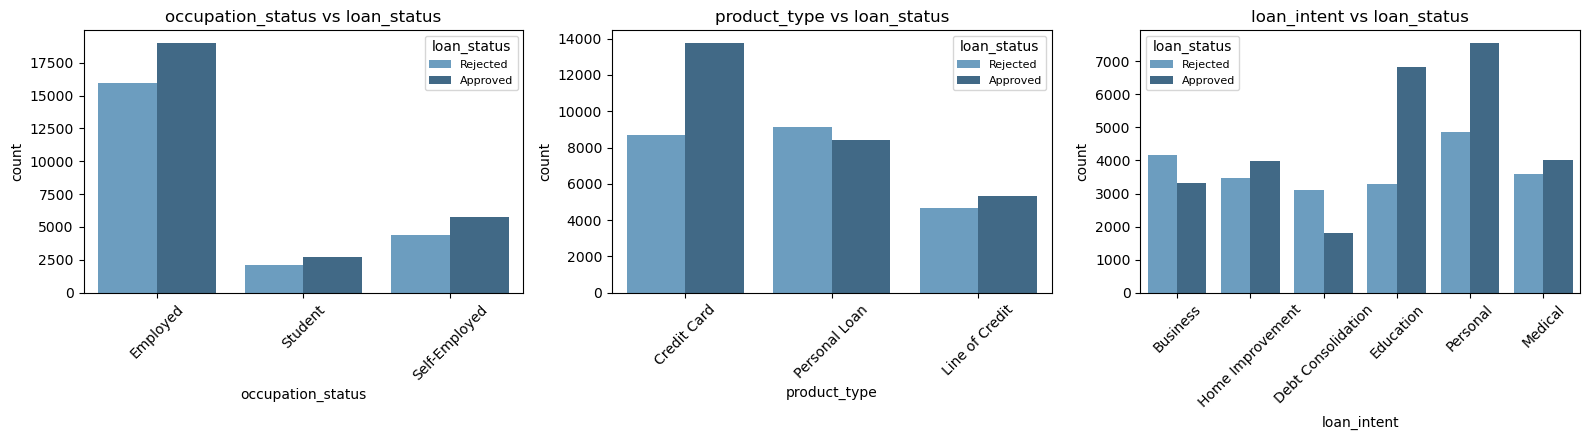

In [41]:
target = "loan_status"   
plt.figure(figsize = (16, 4.5 * nrows))

for i, col in enumerate(cat_columns, 1):
    ax = plt.subplot(nrows, 3, i)
    sns.countplot(data = df, x = col, hue = target, palette = "Blues_d")

    ax.set_title(f"{col} vs {target}")
    ax.tick_params(axis = "x", rotation = 45)
    ax.legend(title = target, fontsize = 8, labels = ["Rejected", "Approved"])

plt.tight_layout()
plt.show()

In [42]:
for col in cat_columns:
    table = pd.crosstab(df[col], df["loan_status"], normalize = "index")
    table = table.rename(columns = {0: "Rejected", 1: "Approved"})

    display(table)

loan_status,Rejected,Approved
occupation_status,,
Employed,0.456435,0.543565
Self-Employed,0.430887,0.569113
Student,0.438969,0.561031


loan_status,Rejected,Approved
product_type,,
Credit Card,0.386774,0.613226
Line of Credit,0.467571,0.532429
Personal Loan,0.519660,0.480340


loan_status,Rejected,Approved
loan_intent,,
Business,0.556567,0.443433
Debt Consolidation,0.633516,0.366484
Education,0.324946,0.675054
Home Improvement,0.464779,0.535221
Medical,0.471045,0.528955
Personal,0.391745,0.608255


In [43]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier

# Feature Engineer ----------------------------------------------------------------

In [44]:
num_features = ["age", "years_employed", "annual_income", "credit_score", "current_debt", "loan_amount"]
cat_features = ["occupation_status", "loan_intent", "product_type"]

In [45]:
deployment_features = ["age", "years_employed", "annual_income", "credit_score", "current_debt", 
                "loan_amount", "occupation_status", "loan_intent", "product_type"]

In [46]:
numeric_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "median")),
    ("scaler", StandardScaler())
])

categorical_transformer = Pipeline(steps = [
    ("imputer", SimpleImputer(strategy = "most_frequent")),
    ("onehot", OneHotEncoder(drop = "first", handle_unknown = "ignore"))
])

preprocessor = ColumnTransformer(
    transformers = [
        ("num", numeric_transformer, num_features),
        ("cat", categorical_transformer, cat_features),
    ],
    remainder = "drop"
)

In [47]:
X = df[deployment_features]
y = df["loan_status"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

In [48]:
modelLogistic = Pipeline(steps = [
    ("preprocessor", preprocessor),
    ("clf", LogisticRegression(max_iter = 1000, class_weight="balanced"))
])

modelLogistic.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'current_debt',
                                                   'loan_amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['occupation_status',
                                                   'loan_intent',
                                                   'product_type'])])),
                ('clf',
                 LogisticRegression(class_weight='balanced', max_iter=1000))])

In [49]:
y_pred_logistic = modelLogistic.predict(X_test)

print("Logistic Regression Results")
print(classification_report(y_test, y_pred_logistic))
print(confusion_matrix(y_test, y_pred_logistic))

Logistic Regression Results
              precision    recall  f1-score   support

           0       0.78      0.82      0.80      4495
           1       0.84      0.81      0.83      5505

    accuracy                           0.81     10000
   macro avg       0.81      0.81      0.81     10000
weighted avg       0.81      0.81      0.81     10000

[[3667  828]
 [1055 4450]]


0 reject
1 approve
TN 3667 rightfully rejected loan
FP 828 wrongfully approved loan
FN 1055 wrongfully rejected loan
TP 4450 rightfully approved loan

In [50]:
modelTree = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", DecisionTreeClassifier(max_depth=4, min_samples_leaf=100, random_state=42))
])

modelTree.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'current_debt',
                                                   'loan_amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(drop='first',
                                                                                 handle_unknown='ignore'))]),
                                                  ['occupation_status',
                                                   'loan_intent',
                                                   'product_type'])])),
                ('model',
                 DecisionTreeClassifier(max_depth=4, min_samples_leaf=100,
                                        random_state=42))])

In [51]:
y_pred_tree = modelTree.predict(X_test)

print("Decision Tree Results")
print(classification_report(y_test, y_pred_tree))
print(confusion_matrix(y_test, y_pred_tree))

Decision Tree Results
              precision    recall  f1-score   support

           0       0.82      0.62      0.71      4495
           1       0.74      0.89      0.81      5505

    accuracy                           0.77     10000
   macro avg       0.78      0.76      0.76     10000
weighted avg       0.78      0.77      0.76     10000

[[2796 1699]
 [ 610 4895]]


0 reject
1 approve
TN 2796 rightfully rejected loan
FP 1699 wrongfully approved loan
FN 610 wrongfully rejected loan
TP 4895 rightfully approved loan

In [52]:
modelXGB = Pipeline(steps= [
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.8, colsample_bytree=0.8, eval_metric="logloss", random_state=42))
])

modelXGB.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['age', 'years_employed',
                                                   'annual_income',
                                                   'credit_score',
                                                   'current_debt',
                                                   'loan_amount']),
                                                 ('cat',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('onehot',
                                                                   OneHotEncoder(dro...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=None,
                               num_parallel_tree=None, ...))])

In [53]:
y_pred_XGB = modelXGB.predict(X_test)

print("XGBClassifier Results")
print(classification_report(y_test, y_pred_XGB))
print(confusion_matrix(y_test, y_pred_XGB))

XGBClassifier Results
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      4495
           1       0.87      0.90      0.88      5505

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000

[[3749  746]
 [ 568 4937]]


0 reject
1 approve
TN 3749 rightfully rejected
FP 746 wrongfully approved
FN 568 wrongfully rejected
TP 4937 rightfully approved

In [54]:
import joblib, os
joblib.dump(modelXGB, "XGBmodel_approval_model.pkl")

['XGBmodel_approval_model.pkl']